# DATA 266 Lab 1 — Task 1  
## Character-Level GPT on TinyStories

**Student:** Omkar Rajale  
**SID4:** 0298  
**SEED:** 298  
**SLICE:** 298  
**HP_ID:** 4  
**CLS_A:** 8  
**CLS_B:** 1  

**Hardware:** NVIDIA RTX 5090  
**Dataset:** TinyStories  
**Training subset:** 100,000 stories  
**Validation subset:** 10,000 stories  

# Step 3: Verify the RTX 5090 environment

In [1]:
import sys
import subprocess
import platform
from datetime import datetime, timezone

print("Python version:", sys.version)
print("Operating system:", platform.platform())

subprocess.run(["nvidia-smi"])

Python version: 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]
Operating system: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
Thu Sep 17 22:07:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.47.03              KMD Version: 610.60        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:01:00.0  On |                  N/A |
|  0%   44C    P5             32W /  575W |    2102MiB /  

CompletedProcess(args=['nvidia-smi'], returncode=0)

In [2]:
print("Execution timestamp:", datetime.now(timezone.utc).isoformat())

Execution timestamp: 2026-09-17T22:07:35.636317+00:00


In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print(
        "GPU VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

PyTorch version: 2.7.1+cu128
PyTorch CUDA version: 12.8
CUDA available: True
GPU name: NVIDIA GeForce RTX 5090
GPU VRAM: 31.84 GB


In [4]:
gpu_command = [
    "nvidia-smi",
    "--query-gpu=name,uuid,driver_version,memory.total,power.limit",
    "--format=csv,noheader"
]

subprocess.run(gpu_command)

NVIDIA GeForce RTX 5090, GPU-f5d856a9-82a5-d9c5-668c-dfc0c6c17517, 610.60, 32607 MiB, 575.00 W


CompletedProcess(args=['nvidia-smi', '--query-gpu=name,uuid,driver_version,memory.total,power.limit', '--format=csv,noheader'], returncode=0)

# Step 4: Install/import the required packages

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch import nn
from torch.utils.data import Dataset, DataLoader

print("Imports successful.")

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports successful.


# Step 5: Set reproducibility seeds

In [6]:
import os
import random
import numpy as np
import torch

SID4 = 298
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print({
    "SID4": f"{SID4:04d}",
    "SEED": SEED,
    "SLICE": SLICE,
    "HP_ID": HP_ID,
    "CLS_A": CLS_A,
    "CLS_B": CLS_B
})

{'SID4': '0298', 'SEED': 298, 'SLICE': 298, 'HP_ID': 4, 'CLS_A': 8, 'CLS_B': 1}


In [7]:
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

Selected device: cuda


# Step 6: Load TinyStories

In [8]:
from getpass import getpass
from huggingface_hub import whoami
from datasets import load_dataset

hf_token = getpass("Enter your Hugging Face token: ")

print("Authenticated as:", whoami(token=hf_token)["name"])

raw_dataset = load_dataset(
    "roneneldan/TinyStories",
    split="train",
    token=hf_token
)

print(raw_dataset)

del hf_token

Enter your Hugging Face token:  ········


Authenticated as: rajaleomkar14
Dataset({
    features: ['text'],
    num_rows: 2119719
})


# Step 7: Creating 100K/10K split

In [9]:
from ftfy import fix_text

In [10]:
original_count = len(raw_dataset)

clean_source_dataset = raw_dataset.filter(
    lambda example: (
        isinstance(example["text"], str)
        and len(example["text"].strip()) > 0
    )
)

removed_count = original_count - len(clean_source_dataset)

print("Original stories:", original_count)
print("Stories after empty-row filtering:", len(clean_source_dataset))
print("Empty or invalid stories removed:", removed_count)

Original stories: 2119719
Stories after empty-row filtering: 2119489
Empty or invalid stories removed: 230


In [11]:
member_split = clean_source_dataset.train_test_split(
    train_size=100_000,
    test_size=10_000,
    seed=SEED,
    shuffle=True
)

train_stories = member_split["train"]
val_stories = member_split["test"]

print("Training stories:", len(train_stories))
print("Validation stories:", len(val_stories))

assert len(train_stories) == 100_000
assert len(val_stories) == 10_000

Training stories: 100000
Validation stories: 10000


# Step 8 — Repair

In [12]:
# how many selected stories may change

train_repair_count = sum(
    fix_text(text) != text
    for text in train_stories["text"]
)

val_repair_count = sum(
    fix_text(text) != text
    for text in val_stories["text"]
)

print("Training stories repaired:", train_repair_count)
print("Validation stories repaired:", val_repair_count)

Training stories repaired: 6040
Validation stories repaired: 623


In [13]:
# Applying repairs 

def repair_story(example):
    return {
        "text": fix_text(example["text"]).strip()
    }


train_stories = train_stories.map(repair_story)
val_stories = val_stories.map(repair_story)

In [14]:
# Checking if non-empty stories remain/not

assert all(
    isinstance(text, str) and len(text) > 0
    for text in train_stories["text"]
)

assert all(
    isinstance(text, str) and len(text) > 0
    for text in val_stories["text"]
)

print("Text repair and validation completed successfully.")

Text repair and validation completed successfully.


# Step 9 — Add story boundaries

In [15]:
STORY_SEPARATOR = "\n\n"

train_text = STORY_SEPARATOR.join(train_stories["text"])
val_text = STORY_SEPARATOR.join(val_stories["text"])

print("Training characters:", len(train_text))
print("Validation characters:", len(val_text))

print("\nExample with story boundary:\n")
first_boundary = len(train_stories[0]["text"])
print(repr(train_text[first_boundary - 100:first_boundary + 102]))

Training characters: 89470351
Validation characters: 8928818

Example with story boundary:

'orry that she had been too tired to try the celery, but she knew she would have another chance soon.\n\nOnce upon a time, a little girl named Lily was playing with her toys in the park. Suddenly, she saw '


In [16]:
import unicodedata

unseen_validation_chars = sorted(
    set(val_text) - set(train_text)
)

print("Number of validation-only characters:",
      len(unseen_validation_chars))

for character in unseen_validation_chars:
    print(
        "Character:", repr(character),
        "| Unicode:", f"U+{ord(character):04X}",
        "| Name:", unicodedata.name(character, "UNKNOWN")
    )

Number of validation-only characters: 1
Character: '―' | Unicode: U+2015 | Name: HORIZONTAL BAR


In [17]:
HORIZONTAL_BAR = "\u2015"

print(
    "Horizontal bars in training:",
    train_text.count(HORIZONTAL_BAR)
)

print(
    "Horizontal bars in validation:",
    val_text.count(HORIZONTAL_BAR)
)

# Normalize the horizontal bar to a regular hyphen.
train_text = train_text.replace(HORIZONTAL_BAR, "-")
val_text = val_text.replace(HORIZONTAL_BAR, "-")

print("U+2015 horizontal bar normalized to '-'.")

Horizontal bars in training: 0
Horizontal bars in validation: 1
U+2015 horizontal bar normalized to '-'.


# Step 10 — Create the vocabulary from the cleaned text

In [18]:
training_characters = set(train_text)
validation_characters = set(val_text)

unseen_validation_chars = (
    validation_characters - training_characters
)

print(
    "Unique training characters:",
    len(training_characters)
)

print(
    "Unique validation characters:",
    len(validation_characters)
)

print(
    "Validation-only characters:",
    repr(unseen_validation_chars)
)

assert len(unseen_validation_chars) == 0

print("No unseen validation characters remain.")

Unique training characters: 114
Unique validation characters: 87
Validation-only characters: set()
No unseen validation characters remain.


In [19]:
# Creating Mappings

vocabulary = sorted(training_characters)

char_to_idx = {
    character: index
    for index, character in enumerate(vocabulary)
}

idx_to_char = {
    index: character
    for character, index in char_to_idx.items()
}

vocab_size = len(vocabulary)

print("Vocabulary size:", vocab_size)
print("First 20 mappings:", list(char_to_idx.items())[:20])

Vocabulary size: 114
First 20 mappings: [('\n', 0), (' ', 1), ('!', 2), ('"', 3), ('$', 4), ('&', 5), ("'", 6), ('(', 7), (')', 8), ('*', 9), ('+', 10), (',', 11), ('-', 12), ('.', 13), ('/', 14), ('0', 15), ('1', 16), ('2', 17), ('3', 18), ('4', 19)]


In [20]:
# Encoding and decoding

def encode(text):
    return [char_to_idx[character] for character in text]


def decode(indices):
    return "".join(
        idx_to_char[int(index)]
        for index in indices
    )

In [21]:
# Test

sample_text = train_text[:200]

encoded_sample = encode(sample_text)
decoded_sample = decode(encoded_sample)

print("Original:")
print(sample_text)

print("\nEncoded:")
print(encoded_sample[:50])

print("\nDecoded:")
print(decoded_sample)

assert decoded_sample == sample_text

print("\nEncoding-decoding test passed.")

Original:
Once upon a time, there was a little girl called Sally. She was three years old and she loved to try new food. Today she was having celery for the first time. She was excited!

Sally looked up at her 

Encoded:
[45, 74, 63, 65, 1, 81, 76, 75, 74, 1, 61, 1, 80, 69, 73, 65, 11, 1, 80, 68, 65, 78, 65, 1, 83, 61, 79, 1, 61, 1, 72, 69, 80, 80, 72, 65, 1, 67, 69, 78, 72, 1, 63, 61, 72, 72, 65, 64, 1, 49]

Decoded:
Once upon a time, there was a little girl called Sally. She was three years old and she loved to try new food. Today she was having celery for the first time. She was excited!

Sally looked up at her 

Encoding-decoding test passed.


# Step 11: Encode the complete datasets

In [22]:
# store the encoded data as uint8 or uint16

import numpy as np

if vocab_size <= 256:
    token_dtype = np.uint8
else:
    token_dtype = np.uint16

print("Vocabulary size:", vocab_size)
print("Storage dtype:", token_dtype)

Vocabulary size: 114
Storage dtype: <class 'numpy.uint8'>


In [23]:
# Encode the text

train_tokens = np.fromiter(
    (char_to_idx[character] for character in train_text),
    dtype=token_dtype,
    count=len(train_text)
)

val_tokens = np.fromiter(
    (char_to_idx[character] for character in val_text),
    dtype=token_dtype,
    count=len(val_text)
)

print("Training tokens:", len(train_tokens))
print("Validation tokens:", len(val_tokens))

print(
    "Training array size:",
    round(train_tokens.nbytes / 1024**2, 2),
    "MB"
)

print(
    "Validation array size:",
    round(val_tokens.nbytes / 1024**2, 2),
    "MB"
)

Training tokens: 89470351
Validation tokens: 8928818
Training array size: 85.33 MB
Validation array size: 8.52 MB


In [24]:
# Verify encoding

decoded_check = decode(train_tokens[:200])

assert decoded_check == train_text[:200]

print("Full-data encoding test passed.")

Full-data encoding test passed.


In [25]:
# reclaim the large text-string memory

import gc

del train_text
del val_text

gc.collect()

print("Original combined text strings removed from memory.")

Original combined text strings removed from memory.


# Step 12: Create fixed-length input–target sequences

In [26]:
BLOCK_SIZE = 256

In [27]:
# Create the dataset class

import torch
from torch.utils.data import Dataset


class CharacterSequenceDataset(Dataset):
    def __init__(self, encoded_tokens, block_size):
        self.tokens = encoded_tokens
        self.block_size = block_size

    def __len__(self):
        return (len(self.tokens) - 1) // self.block_size

    def __getitem__(self, index):
        start = index * self.block_size
        end = start + self.block_size

        input_array = np.asarray(
            self.tokens[start:end],
            dtype=np.int64
        )

        target_array = np.asarray(
            self.tokens[start + 1:end + 1],
            dtype=np.int64
        )

        input_ids = torch.from_numpy(input_array)
        target_ids = torch.from_numpy(target_array)

        return input_ids, target_ids

In [28]:
# Create the training and validation datasets

train_sequence_dataset = CharacterSequenceDataset(
    train_tokens,
    BLOCK_SIZE
)

val_sequence_dataset = CharacterSequenceDataset(
    val_tokens,
    BLOCK_SIZE
)

print("Training sequences:", len(train_sequence_dataset))
print("Validation sequences:", len(val_sequence_dataset))

Training sequences: 349493
Validation sequences: 34878


In [29]:
# Check one input–target pair

sample_input, sample_target = train_sequence_dataset[0]

print("Input shape:", sample_input.shape)
print("Target shape:", sample_target.shape)

print("\nInput text:")
print(repr(decode(sample_input[:200])))

print("\nTarget text:")
print(repr(decode(sample_target[:200])))

Input shape: torch.Size([256])
Target shape: torch.Size([256])

Input text:
'Once upon a time, there was a little girl called Sally. She was three years old and she loved to try new food. Today she was having celery for the first time. She was excited!\n\nSally looked up at her '

Target text:
'nce upon a time, there was a little girl called Sally. She was three years old and she loved to try new food. Today she was having celery for the first time. She was excited!\n\nSally looked up at her m'


# Step 13: Create DataLoaders

In [30]:
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 64
NUM_WORKERS = min(4, os.cpu_count() or 1)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_sequence_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    generator=loader_generator
)

val_loader = DataLoader(
    val_sequence_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

print("Training batches per epoch:", len(train_loader))
print("Validation batches per epoch:", len(val_loader))

In [32]:
# Checking one batch

batch_inputs, batch_targets = next(iter(train_loader))

print("Input batch shape:", batch_inputs.shape)
print("Target batch shape:", batch_targets.shape)
print("Input dtype:", batch_inputs.dtype)
print("Target dtype:", batch_targets.dtype)

Input batch shape: torch.Size([64, 256])
Target batch shape: torch.Size([64, 256])
Input dtype: torch.int64
Target dtype: torch.int64


# Step 14: Set model hyperparameters

In [33]:
MODEL_CONFIG = {
    "vocab_size": vocab_size,
    "block_size": BLOCK_SIZE,
    "embedding_dim": 384,
    "num_heads": 6,
    "num_layers": 6,
    "feedforward_dim": 1536,
    "dropout": 0.1
}

MODEL_CONFIG

{'vocab_size': 114,
 'block_size': 256,
 'embedding_dim': 384,
 'num_heads': 6,
 'num_layers': 6,
 'feedforward_dim': 1536,
 'dropout': 0.1}

In [34]:
assert (
    MODEL_CONFIG["embedding_dim"] %
    MODEL_CONFIG["num_heads"] == 0
)

print(
    "Dimension per attention head:",
    MODEL_CONFIG["embedding_dim"] //
    MODEL_CONFIG["num_heads"]
)

Dimension per attention head: 64


# Step 15: Implement causal multi-head attention manually

In [35]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class CausalMultiHeadSelfAttention(nn.Module):
    def __init__(
        self,
        embedding_dim,
        num_heads,
        block_size,
        dropout
    ):
        super().__init__()

        if embedding_dim % num_heads != 0:
            raise ValueError(
                "embedding_dim must be divisible by num_heads"
            )

        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.head_dim = embedding_dim // num_heads

        # One projection produces queries, keys and values.
        self.qkv_projection = nn.Linear(
            embedding_dim,
            3 * embedding_dim,
            bias=False
        )

        self.output_projection = nn.Linear(
            embedding_dim,
            embedding_dim,
            bias=False
        )

        self.attention_dropout = nn.Dropout(dropout)
        self.output_dropout = nn.Dropout(dropout)

        # Lower-triangular mask:
        # True means the token is visible.
        causal_mask = torch.tril(
            torch.ones(
                block_size,
                block_size,
                dtype=torch.bool
            )
        )

        self.register_buffer(
            "causal_mask",
            causal_mask.view(
                1,
                1,
                block_size,
                block_size
            )
        )

    def forward(self, x):
        batch_size, sequence_length, embedding_dim = x.shape

        qkv = self.qkv_projection(x)

        queries, keys, values = qkv.chunk(3, dim=-1)

        queries = queries.reshape(
            batch_size,
            sequence_length,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        keys = keys.reshape(
            batch_size,
            sequence_length,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        values = values.reshape(
            batch_size,
            sequence_length,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        attention_scores = (
            queries @ keys.transpose(-2, -1)
        ) / math.sqrt(self.head_dim)

        current_mask = self.causal_mask[
            :,
            :,
            :sequence_length,
            :sequence_length
        ]

        attention_scores = attention_scores.masked_fill(
            ~current_mask,
            float("-inf")
        )

        # Calculate softmax in float32 for stability.
        attention_weights = F.softmax(
            attention_scores,
            dim=-1,
            dtype=torch.float32
        ).to(queries.dtype)

        attention_weights = self.attention_dropout(
            attention_weights
        )

        attended_values = attention_weights @ values

        attended_values = attended_values.transpose(
            1,
            2
        ).contiguous().reshape(
            batch_size,
            sequence_length,
            embedding_dim
        )

        output = self.output_projection(attended_values)
        output = self.output_dropout(output)

        return output

# Step 16: Implement the feed-forward network

In [36]:
class FeedForwardNetwork(nn.Module):
    def __init__(
        self,
        embedding_dim,
        feedforward_dim,
        dropout
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                embedding_dim,
                feedforward_dim
            ),
            nn.GELU(),
            nn.Linear(
                feedforward_dim,
                embedding_dim
            ),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.network(x)

# Step 17: Implement one Transformer block

In [37]:
class TransformerBlock(nn.Module):
    def __init__(
        self,
        embedding_dim,
        num_heads,
        feedforward_dim,
        block_size,
        dropout
    ):
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(embedding_dim)

        self.attention = CausalMultiHeadSelfAttention(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            block_size=block_size,
            dropout=dropout
        )

        self.layer_norm_2 = nn.LayerNorm(embedding_dim)

        self.feed_forward = FeedForwardNetwork(
            embedding_dim=embedding_dim,
            feedforward_dim=feedforward_dim,
            dropout=dropout
        )

    def forward(self, x):
        # First residual connection
        x = x + self.attention(
            self.layer_norm_1(x)
        )

        # Second residual connection
        x = x + self.feed_forward(
            self.layer_norm_2(x)
        )

        return x

# Step 18: Build the complete GPT model

In [38]:
class CharacterGPT(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.vocab_size = config["vocab_size"]
        self.block_size = config["block_size"]

        embedding_dim = config["embedding_dim"]

        self.token_embedding = nn.Embedding(
            self.vocab_size,
            embedding_dim
        )

        self.position_embedding = nn.Embedding(
            self.block_size,
            embedding_dim
        )

        self.embedding_dropout = nn.Dropout(
            config["dropout"]
        )

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(
                embedding_dim=embedding_dim,
                num_heads=config["num_heads"],
                feedforward_dim=config["feedforward_dim"],
                block_size=config["block_size"],
                dropout=config["dropout"]
            )
            for _ in range(config["num_layers"])
        ])

        self.final_layer_norm = nn.LayerNorm(
            embedding_dim
        )

        self.language_model_head = nn.Linear(
            embedding_dim,
            self.vocab_size,
            bias=False
        )

        self.apply(self._initialize_weights)

    def _initialize_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

    def forward(self, input_ids, targets=None):
        batch_size, sequence_length = input_ids.shape

        if sequence_length > self.block_size:
            raise ValueError(
                f"Sequence length {sequence_length} exceeds "
                f"block size {self.block_size}"
            )

        positions = torch.arange(
            sequence_length,
            device=input_ids.device
        )

        token_embeddings = self.token_embedding(
            input_ids
        )

        position_embeddings = self.position_embedding(
            positions
        )

        hidden_states = (
            token_embeddings +
            position_embeddings
        )

        hidden_states = self.embedding_dropout(
            hidden_states
        )

        for transformer_block in self.transformer_blocks:
            hidden_states = transformer_block(
                hidden_states
            )

        hidden_states = self.final_layer_norm(
            hidden_states
        )

        logits = self.language_model_head(
            hidden_states
        )

        loss = None

        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(
                    -1,
                    self.vocab_size
                ),
                targets.reshape(-1)
            )

        return logits, loss

# Step 19: Create the model

In [39]:
model = CharacterGPT(MODEL_CONFIG).to(device)

print(model)

CharacterGPT(
  (token_embedding): Embedding(114, 384)
  (position_embedding): Embedding(256, 384)
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (layer_norm_1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attention): CausalMultiHeadSelfAttention(
        (qkv_projection): Linear(in_features=384, out_features=1152, bias=False)
        (output_projection): Linear(in_features=384, out_features=384, bias=False)
        (attention_dropout): Dropout(p=0.1, inplace=False)
        (output_dropout): Dropout(p=0.1, inplace=False)
      )
      (layer_norm_2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (feed_forward): FeedForwardNetwork(
        (network): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1536, out_features=384, bias=True)
          (3): Dropout(p=0.1, inplace=Fa

In [40]:
# Calculating the number of parameters

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Total parameters: 10,824,192
Trainable parameters: 10,824,192


# Step 20: Run a forward-pass test

In [41]:
test_inputs = batch_inputs[:2].to(
    device,
    non_blocking=True
)

test_targets = batch_targets[:2].to(
    device,
    non_blocking=True
)

with torch.no_grad():
    test_logits, test_loss = model(
        test_inputs,
        test_targets
    )

print("Input shape:", test_inputs.shape)
print("Logits shape:", test_logits.shape)
print("Initial loss:", test_loss.item())

Input shape: torch.Size([2, 256])
Logits shape: torch.Size([2, 256, 114])
Initial loss: 4.778108596801758


In [42]:
expected_random_loss = math.log(vocab_size)

print("Expected random-model loss:", expected_random_loss)
print("Observed initial loss:", test_loss.item())

Expected random-model loss: 4.736198448394496
Observed initial loss: 4.778108596801758


# Step 21: Verify causal masking

In [43]:
model.eval()

causal_test_input = batch_inputs[:1, :16].clone().to(device)
modified_input = causal_test_input.clone()

# Change only the final input token.
modified_input[:, -1] = (
    modified_input[:, -1] + 1
) % vocab_size

with torch.no_grad():
    original_logits, _ = model(causal_test_input)
    modified_logits, _ = model(modified_input)

# Earlier output positions must not change.
maximum_earlier_difference = (
    original_logits[:, :-1] -
    modified_logits[:, :-1]
).abs().max().item()

# The final position is allowed to change.
final_position_difference = (
    original_logits[:, -1] -
    modified_logits[:, -1]
).abs().max().item()

print(
    "Maximum difference at earlier positions:",
    maximum_earlier_difference
)

print(
    "Difference at changed/final position:",
    final_position_difference
)

assert maximum_earlier_difference < 1e-5

print("Causal masking test passed.")

Maximum difference at earlier positions: 0.0
Difference at changed/final position: 0.35215020179748535
Causal masking test passed.


In [44]:
model.train()

print("Model implementation and validation completed.")

Model implementation and validation completed.


# Step 22: Training configuration

The model will be trained for 10 epochs using AdamW, BF16 mixed precision, gradient clipping, linear learning-rate warm-up, and cosine learning-rate decay.

In [45]:
from pathlib import Path
from datetime import datetime, timezone
import json
import math
import time

EPOCHS = 10
MAX_LEARNING_RATE = 3e-4
MIN_LEARNING_RATE = 3e-5
WARMUP_RATIO = 0.05
WEIGHT_DECAY = 0.1
MAX_GRAD_NORM = 1.0
LOG_INTERVAL = 200

ARTIFACT_DIR = Path("task1_artifacts")
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
OUTPUT_DIR = ARTIFACT_DIR / "outputs"
RAW_LOG_DIR = ARTIFACT_DIR / "raw_logs"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_LOG_DIR.mkdir(parents=True, exist_ok=True)

RUN_LOG_PATH = RAW_LOG_DIR / "RUN_LOG.txt"

RUN_ID = datetime.now(
    timezone.utc
).strftime("%Y%m%dT%H%M%SZ")

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR / f"{RUN_ID}_best_model.pt"
)

LAST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR / f"{RUN_ID}_last_model.pt"
)

print("Run ID:", RUN_ID)
print("Log path:", RUN_LOG_PATH)
print("Best checkpoint:", BEST_CHECKPOINT_PATH)

Run ID: 20260917T222123Z
Log path: task1_artifacts/raw_logs/RUN_LOG.txt
Best checkpoint: task1_artifacts/checkpoints/20260917T222123Z_best_model.pt


# Step 23: Raw training logger

In [47]:
def log_message(message):
    timestamp = datetime.now(
        timezone.utc
    ).isoformat()

    formatted_message = f"[{timestamp}] {message}"

    print(formatted_message, flush=True)

    with RUN_LOG_PATH.open(
        "a",
        encoding="utf-8"
    ) as log_file:
        log_file.write(formatted_message + "\n")

In [48]:
log_message("=" * 80)
log_message(f"Starting Task 1 training run: {RUN_ID}")
log_message(f"Device: {device}")

if torch.cuda.is_available():
    log_message(
        f"GPU: {torch.cuda.get_device_name(0)}"
    )

log_message(
    f"PyTorch version: {torch.__version__}"
)

log_message(
    f"CUDA version used by PyTorch: {torch.version.cuda}"
)

log_message(
    f"Training stories: {len(train_stories)}"
)

log_message(
    f"Validation stories: {len(val_stories)}"
)

log_message(
    f"Training character tokens: {len(train_tokens):,}"
)

log_message(
    f"Validation character tokens: {len(val_tokens):,}"
)

log_message(
    f"Model parameters: {trainable_parameters:,}"
)

log_message(
    "Model configuration: "
    + json.dumps(MODEL_CONFIG)
)

[2026-09-17T22:21:42.655948+00:00] ================================================================================
[2026-09-17T22:21:42.659361+00:00] Starting Task 1 training run: 20260917T222123Z
[2026-09-17T22:21:42.663422+00:00] Device: cuda
[2026-09-17T22:21:42.667666+00:00] GPU: NVIDIA GeForce RTX 5090
[2026-09-17T22:21:42.671616+00:00] PyTorch version: 2.7.1+cu128
[2026-09-17T22:21:42.675077+00:00] CUDA version used by PyTorch: 12.8
[2026-09-17T22:21:42.679142+00:00] Training stories: 100000
[2026-09-17T22:21:42.682907+00:00] Validation stories: 10000
[2026-09-17T22:21:42.686766+00:00] Training character tokens: 89,470,351
[2026-09-17T22:21:42.691232+00:00] Validation character tokens: 8,928,818
[2026-09-17T22:21:42.695199+00:00] Model parameters: 10,824,192
[2026-09-17T22:21:42.698738+00:00] Model configuration: {"vocab_size": 114, "block_size": 256, "embedding_dim": 384, "num_heads": 6, "num_layers": 6, "feedforward_dim": 1536, "dropout": 0.1}


# Step 24: Configure BF16 and AdamW

In [49]:
USE_BF16 = (
    device.type == "cuda"
    and torch.cuda.is_bf16_supported()
)

print("BF16 enabled:", USE_BF16)

BF16 enabled: True


In [50]:
# Creating the opimizer

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=MAX_LEARNING_RATE,
    betas=(0.9, 0.95),
    eps=1e-8,
    weight_decay=WEIGHT_DECAY,
    fused=(device.type == "cuda")
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: True
    lr: 0.0003
    maximize: False
    weight_decay: 0.1
)


# Step 25: Implement warm-up and cosine scheduling

In [51]:
steps_per_epoch = len(train_loader)
total_training_steps = EPOCHS * steps_per_epoch

warmup_steps = max(
    1,
    int(WARMUP_RATIO * total_training_steps)
)

print("Steps per epoch:", steps_per_epoch)
print("Total training steps:", total_training_steps)
print("Warm-up steps:", warmup_steps)

Steps per epoch: 5460
Total training steps: 54600
Warm-up steps: 2730


In [52]:
# Learning-rate function

def calculate_learning_rate(current_step):
    # Linear warm-up
    if current_step < warmup_steps:
        warmup_fraction = (
            current_step + 1
        ) / warmup_steps

        return (
            MAX_LEARNING_RATE
            * warmup_fraction
        )

    # Cosine decay
    decay_steps = (
        total_training_steps
        - warmup_steps
    )

    decay_progress = (
        current_step - warmup_steps
    ) / max(1, decay_steps)

    decay_progress = min(
        max(decay_progress, 0.0),
        1.0
    )

    cosine_multiplier = 0.5 * (
        1.0
        + math.cos(
            math.pi * decay_progress
        )
    )

    return (
        MIN_LEARNING_RATE
        + (
            MAX_LEARNING_RATE
            - MIN_LEARNING_RATE
        )
        * cosine_multiplier
    )

In [53]:
print(
    "First-step LR:",
    calculate_learning_rate(0)
)

print(
    "End-of-warm-up LR:",
    calculate_learning_rate(warmup_steps)
)

print(
    "Final LR:",
    calculate_learning_rate(
        total_training_steps
    )
)

First-step LR: 1.0989010989010988e-07
End-of-warm-up LR: 0.0003
Final LR: 3e-05


# Step 26: Test one backward pass

In [54]:
model.train()
optimizer.zero_grad(set_to_none=True)

smoke_inputs, smoke_targets = next(
    iter(train_loader)
)

smoke_inputs = smoke_inputs.to(
    device,
    non_blocking=True
)

smoke_targets = smoke_targets.to(
    device,
    non_blocking=True
)

with torch.autocast(
    device_type=device.type,
    dtype=torch.bfloat16,
    enabled=USE_BF16
):
    smoke_logits, smoke_loss = model(
        smoke_inputs,
        smoke_targets
    )

smoke_loss.backward()

smoke_gradient_norm = torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    MAX_GRAD_NORM
)

print("Smoke-test loss:", smoke_loss.item())
print(
    "Smoke-test gradient norm:",
    float(smoke_gradient_norm)
)

assert torch.isfinite(smoke_loss)
assert torch.isfinite(smoke_gradient_norm)

optimizer.zero_grad(set_to_none=True)

del smoke_inputs
del smoke_targets
del smoke_logits
del smoke_loss

torch.cuda.empty_cache()

print("Forward and backward smoke test passed.")

Smoke-test loss: 4.764920234680176
Smoke-test gradient norm: 10.758856773376465
Forward and backward smoke test passed.


# Step 27: Define validation

This function calculates:

- Validation cross-entropy
- Top-1 next-character accuracy
- Number of validation tokens
- Validation speed

In [55]:
@torch.no_grad()
def evaluate_model(model, data_loader):
    model.eval()

    total_loss_sum = 0.0
    total_correct = 0
    total_tokens = 0

    if device.type == "cuda":
        torch.cuda.synchronize()

    evaluation_start = time.perf_counter()

    for input_ids, targets in data_loader:
        input_ids = input_ids.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=USE_BF16
        ):
            logits, loss = model(
                input_ids,
                targets
            )

        number_of_tokens = targets.numel()

        total_loss_sum += (
            loss.item() * number_of_tokens
        )

        predictions = logits.argmax(dim=-1)

        total_correct += (
            predictions == targets
        ).sum().item()

        total_tokens += number_of_tokens

    if device.type == "cuda":
        torch.cuda.synchronize()

    evaluation_time = (
        time.perf_counter()
        - evaluation_start
    )

    average_loss = (
        total_loss_sum / total_tokens
    )

    accuracy = (
        total_correct / total_tokens
    )

    tokens_per_second = (
        total_tokens / evaluation_time
    )

    model.train()

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "tokens": total_tokens,
        "time_seconds": evaluation_time,
        "tokens_per_second": tokens_per_second
    }

# Step 28: Initialize metric tracking

In [56]:
training_history = {
    "epoch": [],
    "train_loss": [],
    "validation_loss": [],
    "validation_accuracy": [],
    "learning_rate": [],
    "gradient_norm_mean": [],
    "gradient_norm_max": [],
    "train_tokens_per_second": [],
    "validation_tokens_per_second": [],
    "epoch_time_seconds": []
}

step_history = {
    "step": [],
    "loss": [],
    "learning_rate": [],
    "gradient_norm": []
}

global_step = 0
nan_count = 0
best_validation_loss = float("inf")

# Step 29: Define checkpoint saving

In [57]:
def save_checkpoint(
    checkpoint_path,
    epoch,
    validation_loss
):
    checkpoint = {
        "run_id": RUN_ID,
        "epoch": epoch,
        "global_step": global_step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "model_config": MODEL_CONFIG,
        "training_config": {
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "max_learning_rate": MAX_LEARNING_RATE,
            "min_learning_rate": MIN_LEARNING_RATE,
            "warmup_ratio": WARMUP_RATIO,
            "weight_decay": WEIGHT_DECAY,
            "max_gradient_norm": MAX_GRAD_NORM,
            "seed": SEED
        },
        "char_to_idx": char_to_idx,
        "idx_to_char": idx_to_char,
        "validation_loss": validation_loss,
        "training_history": training_history,
        "step_history": step_history
    }

    torch.save(
        checkpoint,
        checkpoint_path
    )

# Step 30: Complete 10-epoch training loop

In [58]:
if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

training_start_time = time.perf_counter()

log_message(
    f"Beginning training for {EPOCHS} epochs"
)

for epoch_index in range(EPOCHS):
    epoch_number = epoch_index + 1

    model.train()

    epoch_loss_sum = 0.0
    epoch_token_count = 0
    epoch_gradient_norms = []

    if device.type == "cuda":
        torch.cuda.synchronize()

    epoch_start_time = time.perf_counter()

    log_message(
        f"Epoch {epoch_number}/{EPOCHS} started"
    )

    for batch_index, (
        input_ids,
        targets
    ) in enumerate(train_loader):
        current_learning_rate = (
            calculate_learning_rate(global_step)
        )

        for parameter_group in optimizer.param_groups:
            parameter_group["lr"] = (
                current_learning_rate
            )

        input_ids = input_ids.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=USE_BF16
        ):
            logits, loss = model(
                input_ids,
                targets
            )

        if not torch.isfinite(loss):
            nan_count += 1

            log_message(
                "Non-finite loss detected at "
                f"step {global_step}: "
                f"{loss.item()}"
            )

            raise FloatingPointError(
                "Training stopped because the "
                "loss became non-finite."
            )

        loss.backward()

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM
            )
        )

        if not torch.isfinite(gradient_norm):
            nan_count += 1

            log_message(
                "Non-finite gradient norm detected "
                f"at step {global_step}"
            )

            raise FloatingPointError(
                "Training stopped because gradients "
                "became non-finite."
            )

        optimizer.step()

        number_of_tokens = targets.numel()

        epoch_loss_sum += (
            loss.item() * number_of_tokens
        )

        epoch_token_count += number_of_tokens

        gradient_norm_value = float(
            gradient_norm
        )

        epoch_gradient_norms.append(
            gradient_norm_value
        )

        step_history["step"].append(
            global_step
        )

        step_history["loss"].append(
            loss.item()
        )

        step_history["learning_rate"].append(
            current_learning_rate
        )

        step_history["gradient_norm"].append(
            gradient_norm_value
        )

        global_step += 1

        if (
            batch_index % LOG_INTERVAL == 0
            or batch_index == len(train_loader) - 1
        ):
            log_message(
                f"Epoch {epoch_number}/{EPOCHS} | "
                f"Batch {batch_index + 1}/"
                f"{len(train_loader)} | "
                f"Loss {loss.item():.4f} | "
                f"LR {current_learning_rate:.8f} | "
                f"Grad norm "
                f"{gradient_norm_value:.4f}"
            )

    if device.type == "cuda":
        torch.cuda.synchronize()

    training_epoch_time = (
        time.perf_counter()
        - epoch_start_time
    )

    average_train_loss = (
        epoch_loss_sum / epoch_token_count
    )

    train_tokens_per_second = (
        epoch_token_count / training_epoch_time
    )

    validation_metrics = evaluate_model(
        model,
        val_loader
    )

    complete_epoch_time = (
        training_epoch_time
        + validation_metrics["time_seconds"]
    )

    mean_gradient_norm = float(
        np.mean(epoch_gradient_norms)
    )

    maximum_gradient_norm = float(
        np.max(epoch_gradient_norms)
    )

    training_history["epoch"].append(
        epoch_number
    )

    training_history["train_loss"].append(
        average_train_loss
    )

    training_history["validation_loss"].append(
        validation_metrics["loss"]
    )

    training_history["validation_accuracy"].append(
        validation_metrics["accuracy"]
    )

    training_history["learning_rate"].append(
        current_learning_rate
    )

    training_history["gradient_norm_mean"].append(
        mean_gradient_norm
    )

    training_history["gradient_norm_max"].append(
        maximum_gradient_norm
    )

    training_history[
        "train_tokens_per_second"
    ].append(train_tokens_per_second)

    training_history[
        "validation_tokens_per_second"
    ].append(
        validation_metrics["tokens_per_second"]
    )

    training_history[
        "epoch_time_seconds"
    ].append(complete_epoch_time)

    log_message(
        f"Epoch {epoch_number}/{EPOCHS} completed | "
        f"Train loss {average_train_loss:.4f} | "
        f"Validation loss "
        f"{validation_metrics['loss']:.4f} | "
        f"Validation accuracy "
        f"{validation_metrics['accuracy']:.4%} | "
        f"Train tokens/sec "
        f"{train_tokens_per_second:,.0f} | "
        f"Epoch time "
        f"{complete_epoch_time:.2f}s"
    )

    save_checkpoint(
        LAST_CHECKPOINT_PATH,
        epoch_number,
        validation_metrics["loss"]
    )

    if (
        validation_metrics["loss"]
        < best_validation_loss
    ):
        best_validation_loss = (
            validation_metrics["loss"]
        )

        save_checkpoint(
            BEST_CHECKPOINT_PATH,
            epoch_number,
            validation_metrics["loss"]
        )

        log_message(
            "New best checkpoint saved: "
            f"{BEST_CHECKPOINT_PATH}"
        )

[2026-09-17T22:24:09.475597+00:00] Beginning training for 10 epochs
[2026-09-17T22:24:09.479542+00:00] Epoch 1/10 started
[2026-09-17T22:24:09.671875+00:00] Epoch 1/10 | Batch 1/5460 | Loss 4.7608 | LR 0.00000011 | Grad norm 10.7371
[2026-09-17T22:24:14.286841+00:00] Epoch 1/10 | Batch 201/5460 | Loss 2.5841 | LR 0.00002209 | Grad norm 0.9481
[2026-09-17T22:24:18.864449+00:00] Epoch 1/10 | Batch 401/5460 | Loss 2.3232 | LR 0.00004407 | Grad norm 0.4443
[2026-09-17T22:24:23.476061+00:00] Epoch 1/10 | Batch 601/5460 | Loss 2.2100 | LR 0.00006604 | Grad norm 0.6251
[2026-09-17T22:24:28.177396+00:00] Epoch 1/10 | Batch 801/5460 | Loss 1.9539 | LR 0.00008802 | Grad norm 0.9260
[2026-09-17T22:24:33.223605+00:00] Epoch 1/10 | Batch 1001/5460 | Loss 1.7562 | LR 0.00011000 | Grad norm 1.0604
[2026-09-17T22:24:37.864678+00:00] Epoch 1/10 | Batch 1201/5460 | Loss 1.5699 | LR 0.00013198 | Grad norm 1.0459
[2026-09-17T22:24:42.390591+00:00] Epoch 1/10 | Batch 1401/5460 | Loss 1.4115 | LR 0.00015396

In [59]:
# Finish Timing

if device.type == "cuda":
    torch.cuda.synchronize()

total_training_time_seconds = (
    time.perf_counter()
    - training_start_time
)

if device.type == "cuda":
    peak_memory_bytes = (
        torch.cuda.max_memory_allocated()
    )

    peak_memory_gb = (
        peak_memory_bytes / 1024**3
    )
else:
    peak_memory_bytes = 0
    peak_memory_gb = 0.0

log_message(
    f"Training completed in "
    f"{total_training_time_seconds:.2f} seconds"
)

log_message(
    f"Peak allocated GPU memory: "
    f"{peak_memory_gb:.2f} GB"
)

log_message(
    f"NaN/non-finite count: {nan_count}"
)

log_message(
    f"Best validation loss: "
    f"{best_validation_loss:.4f}"
)

print("Training completed successfully.")

[2026-09-17T22:46:19.784310+00:00] Training completed in 1330.36 seconds
[2026-09-17T22:46:19.789096+00:00] Peak allocated GPU memory: 2.62 GB
[2026-09-17T22:46:19.793737+00:00] NaN/non-finite count: 0
[2026-09-17T22:46:19.798209+00:00] Best validation loss: 0.5637
Training completed successfully.


# Step 31: Load the best checkpoint

In [60]:
best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

best_epoch = best_checkpoint["epoch"]

model.eval()

print("Loaded best checkpoint.")
print("Best epoch:", best_epoch)
print(
    "Stored validation loss:",
    best_checkpoint["validation_loss"]
)

Loaded best checkpoint.
Best epoch: 10
Stored validation loss: 0.5636567628139599


# Step 32: Evaluate the best model

In [61]:
best_validation_metrics = evaluate_model(
    model,
    val_loader
)

best_train_loss = training_history[
    "train_loss"
][best_epoch - 1]

best_val_loss = best_validation_metrics["loss"]
best_val_accuracy = best_validation_metrics["accuracy"]

perplexity = math.exp(best_val_loss)
bits_per_character = best_val_loss / math.log(2)
generalization_gap = best_val_loss - best_train_loss

print(f"Best epoch: {best_epoch}")
print(f"Training loss: {best_train_loss:.6f}")
print(f"Validation loss: {best_val_loss:.6f}")
print(f"Perplexity: {perplexity:.6f}")
print(f"Bits per character: {bits_per_character:.6f}")
print(f"Generalization gap: {generalization_gap:.6f}")
print(f"Top-1 accuracy: {best_val_accuracy:.4%}")

Best epoch: 10
Training loss: 0.574896
Validation loss: 0.563657
Perplexity: 1.757086
Bits per character: 0.813185
Generalization gap: -0.011239
Top-1 accuracy: 81.9339%


# Step 33: Calculate overall training throughput

In [62]:
tokens_per_epoch = (
    len(train_loader)
    * BATCH_SIZE
    * BLOCK_SIZE
)

estimated_training_seconds = sum(
    tokens_per_epoch / throughput
    for throughput in training_history[
        "train_tokens_per_second"
    ]
)

total_training_tokens_processed = (
    tokens_per_epoch * EPOCHS
)

overall_training_tokens_per_second = (
    total_training_tokens_processed
    / estimated_training_seconds
)

print(
    "Training tokens processed:",
    f"{total_training_tokens_processed:,}"
)

print(
    "Overall training tokens/sec:",
    f"{overall_training_tokens_per_second:,.2f}"
)

Training tokens processed: 894,566,400
Overall training tokens/sec: 708,823.24


# Step 34: Plot the training results

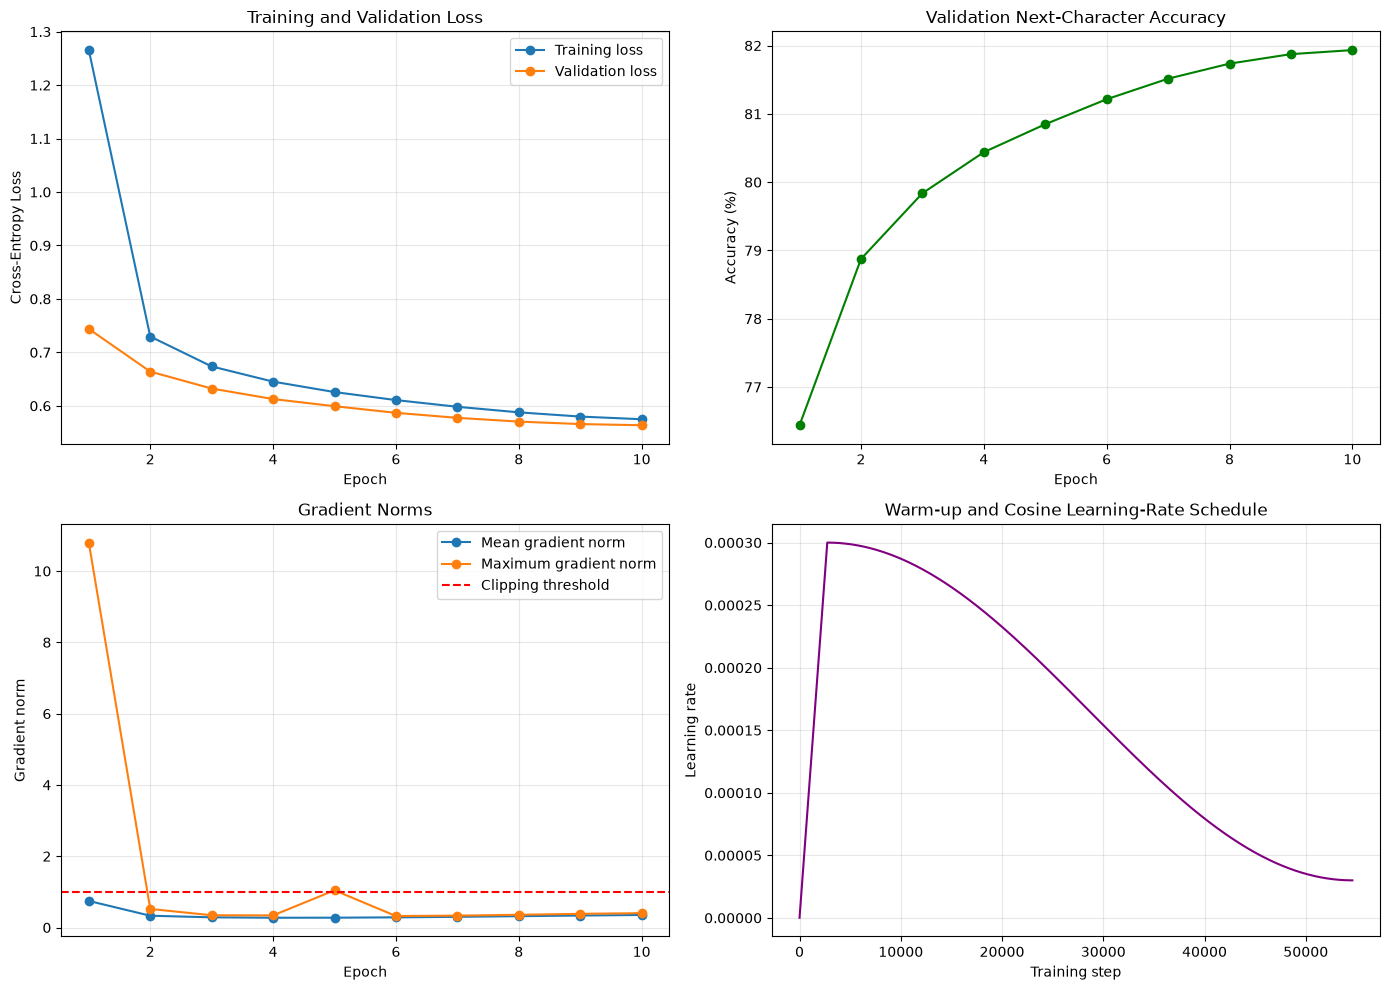

Plot saved to: task1_artifacts/outputs/training_metrics.png


In [63]:
import matplotlib.pyplot as plt

epochs = training_history["epoch"]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# Loss curves
axes[0, 0].plot(
    epochs,
    training_history["train_loss"],
    marker="o",
    label="Training loss"
)

axes[0, 0].plot(
    epochs,
    training_history["validation_loss"],
    marker="o",
    label="Validation loss"
)

axes[0, 0].set_title("Training and Validation Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Cross-Entropy Loss")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# Validation accuracy
axes[0, 1].plot(
    epochs,
    [
        accuracy * 100
        for accuracy in training_history[
            "validation_accuracy"
        ]
    ],
    marker="o",
    color="green"
)

axes[0, 1].set_title(
    "Validation Next-Character Accuracy"
)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].grid(alpha=0.3)

# Gradient norms
axes[1, 0].plot(
    epochs,
    training_history["gradient_norm_mean"],
    marker="o",
    label="Mean gradient norm"
)

axes[1, 0].plot(
    epochs,
    training_history["gradient_norm_max"],
    marker="o",
    label="Maximum gradient norm"
)

axes[1, 0].axhline(
    MAX_GRAD_NORM,
    color="red",
    linestyle="--",
    label="Clipping threshold"
)

axes[1, 0].set_title("Gradient Norms")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Gradient norm")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# Learning rate
axes[1, 1].plot(
    step_history["step"],
    step_history["learning_rate"],
    color="purple"
)

axes[1, 1].set_title(
    "Warm-up and Cosine Learning-Rate Schedule"
)
axes[1, 1].set_xlabel("Training step")
axes[1, 1].set_ylabel("Learning rate")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()

training_plot_path = (
    OUTPUT_DIR / "training_metrics.png"
)

plt.savefig(
    training_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plot saved to:", training_plot_path)

# Step 35: Implement text generation

In [64]:
@torch.inference_mode()
def generate_text(
    model,
    prompt,
    max_new_tokens=500,
    temperature=0.8,
    top_k=40,
    seed=SEED
):
    model.eval()

    normalized_prompt = fix_text(prompt).replace(
        "\u2015",
        "-"
    )

    unknown_characters = (
        set(normalized_prompt) - set(char_to_idx)
    )

    if unknown_characters:
        raise ValueError(
            "Prompt contains unknown characters: "
            f"{unknown_characters}"
        )

    input_ids = torch.tensor(
        encode(normalized_prompt),
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    generated_ids = input_ids

    random_generator = torch.Generator(
        device=device
    )

    random_generator.manual_seed(seed)

    if device.type == "cuda":
        torch.cuda.synchronize()

    generation_start = time.perf_counter()

    for _ in range(max_new_tokens):
        context = generated_ids[
            :,
            -BLOCK_SIZE:
        ]

        with torch.autocast(
            device_type=device.type,
            dtype=torch.bfloat16,
            enabled=USE_BF16
        ):
            logits, _ = model(context)

        next_token_logits = (
            logits[:, -1, :] / temperature
        )

        effective_top_k = min(
            top_k,
            next_token_logits.shape[-1]
        )

        top_values, _ = torch.topk(
            next_token_logits,
            effective_top_k
        )

        cutoff = top_values[:, -1].unsqueeze(-1)

        next_token_logits = (
            next_token_logits.masked_fill(
                next_token_logits < cutoff,
                float("-inf")
            )
        )

        probabilities = torch.softmax(
            next_token_logits,
            dim=-1
        )

        next_token = torch.multinomial(
            probabilities,
            num_samples=1,
            generator=random_generator
        )

        generated_ids = torch.cat(
            [generated_ids, next_token],
            dim=1
        )

    if device.type == "cuda":
        torch.cuda.synchronize()

    generation_time = (
        time.perf_counter() - generation_start
    )

    generated_text = decode(
        generated_ids[0].tolist()
    )

    continuation = generated_text[
        len(normalized_prompt):
    ]

    tokens_per_second = (
        max_new_tokens / generation_time
    )

    return {
        "prompt": normalized_prompt,
        "complete_text": generated_text,
        "continuation": continuation,
        "generated_tokens": max_new_tokens,
        "generation_time_seconds": generation_time,
        "tokens_per_second": tokens_per_second
    }

# Step 36: Generate multiple samples

In [65]:
generation_prompts = [
    "Once upon a time",
    "One day, a little girl named Lily",
    "In a small forest",
    "Tom looked inside the box",
    "The little dog was afraid"
]

generation_results = []

for prompt_index, prompt in enumerate(
    generation_prompts
):
    result = generate_text(
        model=model,
        prompt=prompt,
        max_new_tokens=500,
        temperature=0.8,
        top_k=40,
        seed=SEED + prompt_index
    )

    generation_results.append(result)

    print("=" * 80)
    print("PROMPT:", result["prompt"])
    print()
    print(result["complete_text"])
    print()
    print(
        "Generation speed:",
        f"{result['tokens_per_second']:.2f}",
        "tokens/sec"
    )

PROMPT: Once upon a time

Once upon a time, there was a regular pigeon. He lived in a big field with lots of small, unknown petals. Every day, the pigeon would take him off with him everywhere he went.

One day, a boy named Tim went for a walk with his mom. They saw a big pigeon sitting on the grass. The pigeon wanted to join the restaurant. It said, "Hi, I am Tim." Tim wanted to improve his pigeon.

As they walked, Tim saw a bird. He felt very bad. The bird wanted to help Tim. Tim was a good brother. He wanted to help Tim. But he was n

Generation speed: 290.85 tokens/sec
PROMPT: One day, a little girl named Lily

One day, a little girl named Lily went to the park with her mom. She saw a rose so they could touch it. She wanted to touch it, so she picked it up and touched it. 

But then, a big dog came and examined her. The dog licked her face and said, "Charming, dog." Lily thought the dog was strong and happy, so she picked up the dog. The dog wagged her tail and licked Lily's face. 

In [66]:
generation_output_path = (
    OUTPUT_DIR / "generated_samples.txt"
)

with generation_output_path.open(
    "w",
    encoding="utf-8"
) as output_file:
    for sample_number, result in enumerate(
        generation_results,
        start=1
    ):
        output_file.write(
            f"Sample {sample_number}\n"
        )

        output_file.write(
            f"Prompt: {result['prompt']}\n"
        )

        output_file.write(
            f"Temperature: 0.8\n"
        )

        output_file.write(
            f"Top-k: 40\n"
        )

        output_file.write(
            f"Tokens/sec: "
            f"{result['tokens_per_second']:.2f}\n\n"
        )

        output_file.write(
            result["complete_text"]
        )

        output_file.write(
            "\n\n" + "=" * 80 + "\n\n"
        )

print(
    "Generated samples saved to:",
    generation_output_path
)

Generated samples saved to: task1_artifacts/outputs/generated_samples.txt


# Step 37: Calculate generation-diversity metrics

In [67]:
from collections import Counter


def character_ngrams(text, n):
    return [
        text[index:index + n]
        for index in range(
            len(text) - n + 1
        )
    ]


def distinct_n(text, n):
    ngrams = character_ngrams(text, n)

    if not ngrams:
        return 0.0

    return len(set(ngrams)) / len(ngrams)


def repeated_ngram_rate(text, n=4):
    ngrams = character_ngrams(text, n)

    if not ngrams:
        return 0.0

    unique_ngrams = len(set(ngrams))

    return 1.0 - (
        unique_ngrams / len(ngrams)
    )

In [68]:
all_generated_text = "\n".join(
    result["continuation"]
    for result in generation_results
)

distinct_1 = distinct_n(
    all_generated_text,
    1
)

distinct_2 = distinct_n(
    all_generated_text,
    2
)

distinct_3 = distinct_n(
    all_generated_text,
    3
)

repeated_4gram_rate = repeated_ngram_rate(
    all_generated_text,
    4
)

average_generation_tokens_per_second = (
    np.mean([
        result["tokens_per_second"]
        for result in generation_results
    ])
)

print(f"Distinct-1: {distinct_1:.6f}")
print(f"Distinct-2: {distinct_2:.6f}")
print(f"Distinct-3: {distinct_3:.6f}")

print(
    "Repeated 4-gram rate:",
    f"{repeated_4gram_rate:.6f}"
)

print(
    "Average generation tokens/sec:",
    f"{average_generation_tokens_per_second:.2f}"
)

Distinct-1: 0.017572
Distinct-2: 0.133839
Distinct-3: 0.356115
Repeated 4-gram rate: 0.460616
Average generation tokens/sec: 336.46


# Sequence Model Failure Analysis

The following failure cases were identified from text generated using temperature = 0.8 and top-k = 40.

## Failure Case 1: Repetition

**Prompt:**  
`The little dog was afraid`

**Generated snippet:**  
> "The little dog was so scared that he started to cry. The little dog was so scared that he started to cry."

**Failure type:** Repetition

**Observation:**  
The model generated the exact same sentence twice consecutively. It understood that the dog was scared, but it became stuck on the same sentence instead of continuing the story with a new event. This indicates limited generation diversity and is also reflected by the repeated 4-gram metric.

---

## Failure Case 2: Pronoun and Entity Inconsistency

**Prompt:**  
`Tom looked inside the box`

**Generated snippet:**  
> "Tom looked inside the box and saw a man with a big cart and a blue cart. She was happy to see him and felt sorry for him."

**Failure type:** Broken grammar and inconsistent entity references

**Observation:**  
The story begins with Tom and a man, but the next sentence suddenly uses the pronoun "She" without introducing a female character. It is unclear whether "She" refers to Tom, the man, or a new character. The model produces locally correct sentences but does not consistently track character identity.

---

## Failure Case 3: Loss of Coherence and Unsupported Details

**Prompt:**  
`Tom looked inside the box`

**Generated snippet:**  
> "Thank you! Thank you for helping me find my glue and my doll."  
> "Please, let's find your glue and your car."

**Failure type:** Loss of coherence / unsupported details

**Observation:**  
The model suddenly introduces missing glue and a doll even though neither was mentioned earlier. It then changes the doll into a car. These objects and the search objective are not supported by the previous story context. This shows that the model can generate grammatically reasonable sentences while losing track of the overall storyline.